# 04. Feature Transformation: Scaling and Encoding
## 📚 Learning Objectives

By completing this notebook, you will:
- Transform features using scaling techniques
- Encode categorical variables for machine learning
- Scale numerical features (StandardScaler, MinMaxScaler)
- Encode categorical features (Label, One-Hot encoding)
- Prepare data for ML models

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 07 (encoding categorical features) and Course 04 (AIAT 114) — Unit 1, lesson 03 — the same scaling and encoding, now as a repeatable transformation step.

**Used later in:** Course 05 — Unit 4, lesson 02, and Course 12 (AIAT 126) — Unit 3, which preprocesses graduation-project data this way.

---

This notebook covers practical activities from **Course 05, Unit 2**:
- Feature Transformation: Transforming data (e.g., scaling, encoding) to prepare it for analysis

---

## The Story: Preparing Ingredients for Cooking

Imagine you're cooking. **Before** you can cook, you need to prepare ingredients - cut vegetables to same size (scaling), convert different units to same measure (encoding). **After** preparing properly, all ingredients are ready to cook together!

Same with data: **Before** machine learning, we transform features - scale numbers to same range, encode categories to numbers. **After** transforming, all features are ready for models!

---

## Why Feature Transformation Matters

Feature transformation is essential because:
- **Scaling**: Makes features comparable (prevents one feature from dominating)
- **Encoding**: Converts categories to numbers (ML algorithms need numbers)
- **Performance**: Properly transformed data improves model performance
- **Accuracy**: Scaling helps distance-based algorithms (KNN, SVM)

**Common Student Questions:**
- **Q: When do I scale vs encode?**
  - Answer: Scale numerical features, encode categorical features
  - Example: Age (numerical) → scale, Color (categorical) → encode
  - Rule: Numbers → scale, Categories → encode
  
- **Q: Which scaler should I use?**
  - Answer: StandardScaler for normal distributions, MinMaxScaler for bounded ranges
  - Example: StandardScaler: mean=0, std=1; MinMaxScaler: range [0,1]
  - Tip: Try both and see which works better for your data

---

## Introduction

**Feature transformation** prepares data for analysis by scaling numerical features and encoding categorical variables. This is essential for machine learning, as models require features in specific formats.


## 🎯 The case: Amazon's résumé scorer, and what an encoding can smuggle in

From 2014 Amazon built an experimental engine to score job applicants from one to five
stars, trained on résumés submitted to the company over the previous ten years. By 2015
the team knew it was broken. As Reuters reported (Jeffrey Dastin, October 2018), the model
**penalised résumés containing the word "women's"** — as in "women's chess club captain" —
and **downgraded graduates of two all-women's colleges**. Nobody had encoded a gender
column. The model learned gender from the text, because ten years of tech-industry résumés
carried it. Amazon abandoned the project.

That is the sharp edge of this lesson. **How you turn a category into a number is a claim,
not a formatting step.** Label-encode a nominal column and you assert an order that does
not exist. One-hot encode a high-cardinality column and you assert that every level is
independent. Encode a proxy for something you are not allowed to use, and you have used it.

**What goes wrong without deliberate encoding and scaling.** Two failures, both silent: a
model that learns a protected attribute you never gave it, and a model that cannot hear a
feature because its numbers are small. Neither raises an error.

**And on the numeric side, here it is measured.** You will see it measured below: in this
manifest, `Fare` spans **0 to 512.33** while `family_size` spans **1 to 11**. Feed those
raw into any method that measures distance — k-nearest neighbours, k-means, an SVM with an
RBF kernel — and the arithmetic literally cannot hear family size. The model is not
ignoring it because family size does not matter. It is ignoring it because pounds are
bigger numbers than people.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Raw features
- pandas, sklearn (scaling, encoding)

**Outputs:** What you'll see when you run the cells

- Scaled/encoded features
- Printed results

---

In [1]:
# WHAT: Import pandas, NumPy, and the sklearn preprocessing tools used below.
# WHY: Scalers put numeric features on comparable ranges and encoders turn categories into numbers - the two jobs of this notebook.

# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

In [2]:
# WHAT: Load the real manifest and put three real numeric columns on comparable scales.
# WHY: Age, Fare and family size live on wildly different ranges - any distance-based model would let Fare dominate.

# ============================================================================
# PART 1: SCALING NUMERICAL FEATURES
# ============================================================================
print("\n📊 PART 1: Scaling Numerical Features")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
titanic = load("titanic")

# Fill the 177 genuinely missing ages by (class, sex) median, as Example 2 concluded.
titanic['Age'] = titanic.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda s: s.fillna(s.median()))
titanic['family_size'] = titanic['SibSp'] + titanic['Parch'] + 1

print("\n✅ Example: Real Columns on Very Different Scales")
print("-" * 70)

data = titanic[['Age', 'Fare', 'family_size']].copy()
print("First 5 rows of the real data:")
print(data.head())
print("\nRanges actually present in the file:")
for col in data.columns:
    print(f"   {col:<12} {data[col].min():>8.2f} .. {data[col].max():>8.2f}")
print("\nProblem: Fare spans 0-512 while family_size spans 1-11 - a model that")
print("measures distance would hear Fare and ignore family size entirely.")
print("Solution: put every feature on a comparable scale.")

# StandardScaler (mean=0, std=1)
print("\n✅ Method 1: StandardScaler (mean=0, std=1)")
print("-" * 70)
scaler_standard = StandardScaler()
data_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(data),
    columns=data.columns,
)
print("Scaled data (StandardScaler), first 5 rows:")
print(data_scaled_standard.head().round(3))
print(f"\nMean: {data_scaled_standard.mean().round(6).values}")
print(f"Std:  {data_scaled_standard.std().round(4).values}")

# MinMaxScaler (range [0, 1])
print("\n✅ Method 2: MinMaxScaler (range [0, 1])")
print("-" * 70)
scaler_minmax = MinMaxScaler()
data_scaled_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(data),
    columns=data.columns,
)
print("Scaled data (MinMaxScaler), first 5 rows:")
print(data_scaled_minmax.head().round(3))
print(f"\nMin: {data_scaled_minmax.min().values}")
print(f"Max: {data_scaled_minmax.max().values}")
print(f"\n⚠ On real skewed data the two behave very differently. Median Fare after")
print(f"   StandardScaler: {data_scaled_standard['Fare'].median():.3f};"
      f" after MinMaxScaler: {data_scaled_minmax['Fare'].median():.3f}.")
print("   MinMax hands the whole top of the range to a handful of rich passengers.")



📊 PART 1: Scaling Numerical Features
----------------------------------------------------------------------
titanic: full file, 891 rows.

✅ Example: Real Columns on Very Different Scales
----------------------------------------------------------------------
First 5 rows of the real data:
    Age     Fare  family_size
0  22.0   7.2500            2
1  38.0  71.2833            2
2  26.0   7.9250            1
3  35.0  53.1000            2
4  35.0   8.0500            1

Ranges actually present in the file:
   Age              0.42 ..    80.00
   Fare             0.00 ..   512.33
   family_size      1.00 ..    11.00

Problem: Fare spans 0-512 while family_size spans 1-11 - a model that
measures distance would hear Fare and ignore family size entirely.
Solution: put every feature on a comparable scale.

✅ Method 1: StandardScaler (mean=0, std=1)
----------------------------------------------------------------------
Scaled data (StandardScaler), first 5 rows:
     Age   Fare  family_size
0 -

Share of the distance between two passengers that each feature is responsible for:
scaling                                      Age          Fare   family_size
Raw units (pounds, years, people)           6.7%         93.2%          0.1%
StandardScaler                             33.3%         33.3%         33.3%
MinMaxScaler                               44.1%         14.8%         41.1%


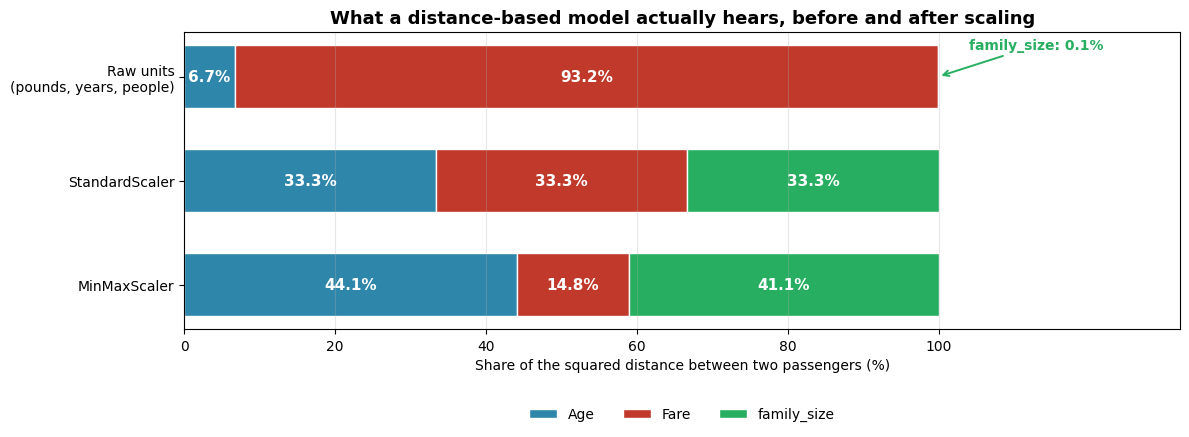

In [3]:
# WHAT: Measure how much each feature actually contributes to the distance between two passengers.
# WHY: "Fare dominates" is the claim of this whole section. Rather than assert it, we compute
#      the average squared difference between every pair of passengers, feature by feature -
#      which IS the quantity a kNN / k-means / RBF-SVM adds up when it compares two people.

import matplotlib.pyplot as plt

def distance_share(frame):
    """Average squared gap between two passengers, split per feature, as a percentage."""
    M = frame.values.astype(float)
    # M[:, None, :] - M[None, :, :] is every passenger minus every other passenger.
    per_feature = ((M[:, None, :] - M[None, :, :]) ** 2).mean(axis=(0, 1))
    return per_feature / per_feature.sum() * 100

variants = {
    'Raw units\n(pounds, years, people)': distance_share(data),
    'StandardScaler': distance_share(data_scaled_standard),
    'MinMaxScaler': distance_share(data_scaled_minmax),
}
features = list(data.columns)
colours = {'Age': '#2E86AB', 'Fare': '#C0392B', 'family_size': '#27AE60'}

print("Share of the distance between two passengers that each feature is responsible for:")
print(f"{'scaling':<34}" + "".join(f"{f:>14}" for f in features))
for name, shares in variants.items():
    label = name.replace('\n', ' ')
    print(f"{label:<34}" + "".join(f"{v:>13.1f}%" for v in shares))

fig, ax = plt.subplots(figsize=(12, 4.6))
left = np.zeros(len(variants))
ypos = np.arange(len(variants))
for k, feat in enumerate(features):
    widths = np.array([shares[k] for shares in variants.values()])
    ax.barh(ypos, widths, left=left, color=colours[feat], edgecolor='white',
            height=0.6, label=feat)
    for y, (w, l) in enumerate(zip(widths, left)):
        if w > 4:
            ax.text(l + w / 2, y, f'{w:.1f}%', ha='center', va='center',
                    color='white', fontsize=11, weight='bold')
        else:
            # A slice this thin is invisible - say so in the margin, with a pointer,
            # because "too small to draw" is exactly the finding.
            ax.annotate(f'{feat}: {w:.1f}%', xy=(l + w, y), xytext=(104, y - 0.30),
                        fontsize=10, weight='bold', color=colours[feat], va='center',
                        arrowprops=dict(arrowstyle='->', color=colours[feat], lw=1.4))
    left += widths
ax.set_yticks(ypos)
ax.set_yticklabels(list(variants.keys()), fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 132)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlabel('Share of the squared distance between two passengers (%)')
ax.set_title('What a distance-based model actually hears, before and after scaling',
             fontsize=13, weight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3,
          fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


**Read the figure.** Each bar is 100% of the distance one of these models computes between
two passengers, split by which feature produced it.

*Top* — in raw units, `Fare` accounts for **93.2%** of it, `Age` for 6.7%, and
`family_size` for **0.1%**. That is the claim from the top of this notebook, measured: a
k-nearest-neighbours model asked to find "similar passengers" here is, to within a rounding
error, sorting people by ticket price. Family size is not being weighed lightly — it is not
being weighed at all.

*Middle* — after `StandardScaler` every feature contributes exactly one third. The scaler
divides each column by its own standard deviation, so by construction all three arrive with
the same spread. That is the state most distance-based models assume you gave them.

*Bottom* — `MinMaxScaler` does **not** produce thirds. `Fare` drops to 14.8% while `Age`
and `family_size` take 44.1% and 41.1%. The reason is lesson 03's: min-max divides by the
range, and the £512 ticket makes `Fare`'s range enormous, so almost every passenger ends up
crushed into the bottom of that column and stops varying. Choosing a scaler is choosing
which feature your model listens to — it is not a formatting decision.


In [4]:
# WHAT: Encode the real categorical columns of the manifest - ordinal class and nominal port/sex.
# WHY: ML algorithms consume numbers; HOW you turn a category into a number encodes a claim about whether it has an order.

# ============================================================================
# PART 2: ENCODING CATEGORICAL FEATURES
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Encoding Categorical Features")
print("=" * 70)

print("\n✅ Example: The Real Categorical Columns")
print("-" * 70)

cat_data = titanic[['Sex', 'Pclass', 'Embarked']].copy()
print("Original categorical data (first 5 rows):")
print(cat_data.head())
print("\nWhat is actually in them:")
for col in cat_data.columns:
    counts = cat_data[col].value_counts(dropna=False).to_dict()
    print(f"   {col:<9} {counts}")
print("\nNote Embarked has 2 NaN - encoders do NOT silently handle that, you do.")
print("\nProblem: ML algorithms need numbers, not text!")
print("Solution: Encode categories to numbers")

# Ordinal Encoding - for categories that genuinely have an order
print("\n✅ Method 1: Ordinal Encoding (ordered categories)")
print("-" * 70)
# Pclass is ORDERED: 1st class outranks 2nd outranks 3rd. Encoding it as 1/2/3
# is honest, because the distance between the numbers means something.
class_order = {1: 2, 2: 1, 3: 0}   # higher number = better class
cat_data['class_rank'] = cat_data['Pclass'].map(class_order)
print("Pclass mapped to a rank (3rd=0, 2nd=1, 1st=2):")
print(cat_data[['Pclass', 'class_rank']].drop_duplicates().sort_values('Pclass'))
print("\n💡 Use an explicit mapping for ordinal categories so YOU choose the order.")
print("💡 Caution: sklearn's LabelEncoder sorts labels alphabetically - fine for")
print("   target labels, wrong for ordered features.")

# One-Hot Encoding - for categories with no order
print("\n✅ Method 2: One-Hot Encoding (nominal categories)")
print("-" * 70)
# Embarked is NOMINAL: Cherbourg is not 'more' than Queenstown. Numbering the
# ports 0/1/2 would invent an order that does not exist.
onehot_encoded = pd.get_dummies(cat_data[['Embarked']], prefix='port', dummy_na=True)
print("One-Hot encoded 'Embarked' (first 5 rows):")
print(onehot_encoded.head())
print(f"\nColumns created: {list(onehot_encoded.columns)}")
print("💡 dummy_na=True gave the 2 missing values their own column instead of")
print("   quietly encoding them as 'not any port', which would be a lie.")
print("💡 Use one-hot for nominal categories (S ≠ C ≠ Q, no order).")



PART 2: Encoding Categorical Features

✅ Example: The Real Categorical Columns
----------------------------------------------------------------------
Original categorical data (first 5 rows):
      Sex  Pclass Embarked
0    male       3        S
1  female       1        C
2  female       3        S
3  female       1        S
4    male       3        S

What is actually in them:
   Sex       {'male': 577, 'female': 314}
   Pclass    {3: 491, 1: 216, 2: 184}
   Embarked  {'S': 644, 'C': 168, 'Q': 77, nan: 2}

Note Embarked has 2 NaN - encoders do NOT silently handle that, you do.

Problem: ML algorithms need numbers, not text!
Solution: Encode categories to numbers

✅ Method 1: Ordinal Encoding (ordered categories)
----------------------------------------------------------------------
Pclass mapped to a rank (3rd=0, 2nd=1, 1st=2):
   Pclass  class_rank
1       1           2
9       2           1
0       3           0

💡 Use an explicit mapping for ordinal categories so YOU choose the or

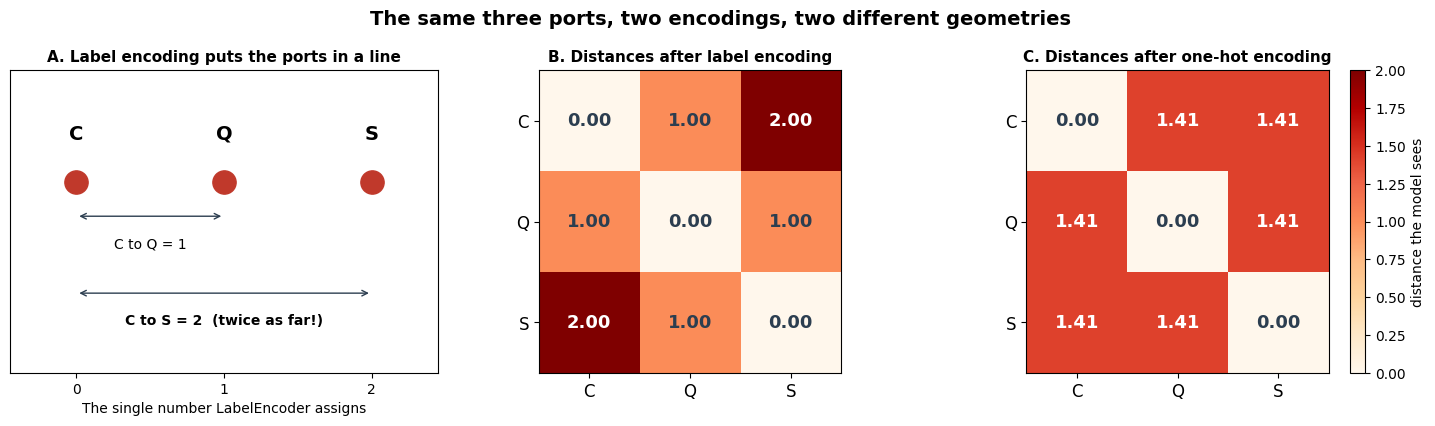

Distances a model would compute between the three ports:
   C (Cherbourg)    to Q (Queenstown)    label encoding: 1.00   one-hot: 1.41
   C (Cherbourg)    to S (Southampton)   label encoding: 2.00   one-hot: 1.41
   Q (Queenstown)   to S (Southampton)   label encoding: 1.00   one-hot: 1.41

Label encoding says Cherbourg is twice as far from Southampton as from
Queenstown. Nothing in the data says that. One-hot makes all three equally
far apart, which is the honest statement when a category has no order.


In [5]:
# WHAT: Draw the geometry each encoding imposes on the three ports of embarkation.
# WHY: An encoding is not a formatting step - it hands the model a set of distances.
#      Here are the distances the two encodings actually produce.

import matplotlib.pyplot as plt

ports = ['C (Cherbourg)', 'Q (Queenstown)', 'S (Southampton)']
short = ['C', 'Q', 'S']

# LabelEncoder sorts alphabetically: C -> 0, Q -> 1, S -> 2. One number per port.
label_coords = np.array([[0.0], [1.0], [2.0]])
# One-hot: each port becomes its own axis, so no port is between any other two.
onehot_coords = np.eye(3)

def pairwise(coords):
    return np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

D_label, D_onehot = pairwise(label_coords), pairwise(onehot_coords)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
fig.suptitle('The same three ports, two encodings, two different geometries',
             fontsize=14, weight='bold')

# Panel A - the number line LabelEncoder puts the ports on.
ax = axes[0]
ax.scatter(label_coords[:, 0], [0, 0, 0], s=280, color='#C0392B', zorder=3)
for x, name in zip(label_coords[:, 0], short):
    ax.text(x, 0.16, name, ha='center', fontsize=14, weight='bold')
ax.annotate('', xy=(0, -0.13), xytext=(1, -0.13),
            arrowprops=dict(arrowstyle='<->', color='#2c3e50'))
ax.text(0.5, -0.25, 'C to Q = 1', ha='center', fontsize=10)
ax.annotate('', xy=(0, -0.42), xytext=(2, -0.42),
            arrowprops=dict(arrowstyle='<->', color='#2c3e50'))
ax.text(1.0, -0.54, 'C to S = 2  (twice as far!)', ha='center', fontsize=10, weight='bold')
ax.set_xlim(-0.45, 2.45)
ax.set_ylim(-0.72, 0.42)
ax.set_yticks([])
ax.set_xticks([0, 1, 2])
ax.set_xlabel('The single number LabelEncoder assigns')
ax.set_title('A. Label encoding puts the ports in a line', fontsize=11, weight='bold')

# Panels B and C - the resulting distance matrices, on one shared colour scale.
for ax, D, title in [(axes[1], D_label, 'B. Distances after label encoding'),
                     (axes[2], D_onehot, 'C. Distances after one-hot encoding')]:
    im = ax.imshow(D, cmap='OrRd', vmin=0, vmax=2)
    for r in range(3):
        for c in range(3):
            ax.text(c, r, f'{D[r, c]:.2f}', ha='center', va='center', fontsize=13,
                    weight='bold', color='white' if D[r, c] > 1.2 else '#2c3e50')
    ax.set_xticks(range(3)); ax.set_xticklabels(short, fontsize=12)
    ax.set_yticks(range(3)); ax.set_yticklabels(short, fontsize=12)
    ax.set_title(title, fontsize=11, weight='bold')
fig.colorbar(im, ax=axes[2], fraction=0.046, label='distance the model sees')

plt.tight_layout()
plt.show()

print("Distances a model would compute between the three ports:")
for r in range(3):
    for c in range(r + 1, 3):
        print(f"   {ports[r]:<16} to {ports[c]:<16}"
              f"  label encoding: {D_label[r, c]:.2f}   one-hot: {D_onehot[r, c]:.2f}")
print("\nLabel encoding says Cherbourg is twice as far from Southampton as from")
print("Queenstown. Nothing in the data says that. One-hot makes all three equally")
print("far apart, which is the honest statement when a category has no order.")


**Read the figure.** *A* — `LabelEncoder` sorts the labels alphabetically and hands back one
number each: C→0, Q→1, S→2. That places the three ports on a line, and a line has distances.
Cherbourg now sits twice as far from Southampton as from Queenstown, and Queenstown sits
exactly halfway between the other two. No one decided that; alphabetical order did.

*B* — the same statement as a distance matrix. Read the top row: C→Q is 1.00 and C→S is
2.00. Any model that measures distance takes those numbers literally.

*C* — the same three ports after one-hot encoding, on the same colour scale. Every
off-diagonal cell is 1.41 (that is √2). No port is between any other two, and no port is
"more" than another. Panels B and C are pictures of two different claims about the world,
and only one of them is a claim the ticket data supports.

`Pclass` is the interesting counter-example in this notebook: it was mapped to a rank on
purpose, because first class really does outrank third. The question worth arguing about —
and question 1 under 💬 Discuss asks it — is whether the gap between 1st and 2nd is truly the
same size as the gap between 2nd and 3rd, which is what the numbers 2, 1, 0 assert.


In [6]:
# WHAT: Run the full scale+encode pipeline on the real manifest and produce a model-ready matrix.
# WHY: This is the exact handoff between Unit 2 (cleaning) and Unit 4 (modelling) - numbers only, no text, no gaps.

# ============================================================================
# PART 3: REAL-WORLD EXAMPLE
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Real-World Example")
print("=" * 70)

print("\n📊 Example: Prepare the Titanic Manifest for an ML Model")
print("-" * 70)

# Start from the real columns a survival model would plausibly use.
ml_data = titanic[['Age', 'Fare', 'family_size', 'Sex', 'Embarked', 'Pclass']].copy()
# Embarked still has 2 gaps; fill with the most common port before encoding.
ml_data['Embarked'] = ml_data['Embarked'].fillna(ml_data['Embarked'].mode()[0])

print("Original data (first 5 rows):")
print(ml_data.head())
print(f"Shape before transformation: {ml_data.shape}")

# Scale numerical features
numerical_cols = ['Age', 'Fare', 'family_size']
scaler = StandardScaler()
ml_data[numerical_cols] = scaler.fit_transform(ml_data[numerical_cols])

# Encode categorical features
# drop_first=True avoids the dummy trap: with 3 ports, 2 columns already say which.
ml_data = pd.get_dummies(ml_data, columns=['Sex', 'Embarked', 'Pclass'],
                         prefix=['sex', 'port', 'class'], drop_first=True)

print("\nTransformed data (ready for ML), first 5 rows:")
print(ml_data.head().round(3))
print(f"\nShape after transformation: {ml_data.shape}")
print(f"Columns: {list(ml_data.columns)}")
print(f"Any text columns left? {(ml_data.dtypes == 'object').sum()}")
print(f"Any missing values left? {ml_data.isnull().sum().sum()}")
print("\n✅ All features are now: scaled numerical + encoded categorical")
print("   This matrix is exactly what Unit 4's models will accept.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Scaling: StandardScaler (mean=0, std=1), MinMaxScaler (range [0,1])
   2. Encoding: Ordinal Encoding (ordered), One-Hot Encoding (nominal)
   3. When to use: Scale numerical, encode categorical
   4. Real-world: Prepared the actual Titanic manifest for a model

🎯 Key Takeaways:
   - Scaling: Makes numerical features comparable
   - Encoding: Converts categories to numbers
   - StandardScaler: For roughly symmetric distributions
   - MinMaxScaler: For bounded ranges - but extremes define the bounds
   - Ordinal Encoding: Ordered categories (ticket class)
   - One-Hot Encoding: Nominal categories (port of boarding)
   - Missing categories need a deliberate decision BEFORE encoding

📚 Next Steps:
   - Example 5: EDA Visualizations (explore your transformed data!)
   - Example 6: Statistical EDA (summaries, correlations)
   - Unit 4: Machine Learning (use transformed data for models)
""")
print("✅ Feature transformation concepts understood!")



PART 3: Real-World Example

📊 Example: Prepare the Titanic Manifest for an ML Model
----------------------------------------------------------------------
Original data (first 5 rows):
    Age     Fare  family_size     Sex Embarked  Pclass
0  22.0   7.2500            2    male        S       3
1  38.0  71.2833            2  female        C       1
2  26.0   7.9250            1  female        S       3
3  35.0  53.1000            2  female        S       1
4  35.0   8.0500            1    male        S       3
Shape before transformation: (891, 6)

Transformed data (ready for ML), first 5 rows:
     Age   Fare  family_size  sex_male  port_Q  port_S  class_2  class_3
0 -0.535 -0.502        0.059      True   False    True    False     True
1  0.668  0.787        0.059     False   False   False    False    False
2 -0.234 -0.489       -0.561     False   False    True    False     True
3  0.443  0.421        0.059     False   False    True    False    False
4  0.443 -0.486       -0.561     

## ⚠️ Where this breaks

- **Fit on train, transform everything — or you have leaked.** `StandardScaler` learns the
  mean and standard deviation of the data you fit it on. Fitting on the full dataset before
  splitting lets test-set information into training, and your validation score becomes a
  lie. Put the scaler inside a `Pipeline` (Unit 5 lesson 05) so this cannot happen by
  accident.
- **Scalers are defined by statistics that outliers control.** `MinMaxScaler` is defined by
  the two most extreme values — lesson 03 measured the median fare landing at **0.028** for
  exactly this reason. `StandardScaler` uses the mean and standard deviation, both inflated
  by a skewed tail. On money-like columns prefer `RobustScaler` (median and IQR) or
  transform the shape first.
- **Unseen categories break one-hot encoding at inference time.** A passenger boarding at a
  fourth port produces a column your model has never seen. `OneHotEncoder(handle_unknown=
  'ignore')` is not optional in production; it is the difference between a wrong answer and
  a 500 error.
- **One-hot explodes on high cardinality.** Three ports give three columns. Postcodes,
  product SKUs or IP addresses give tens of thousands, most of them almost always zero.
  Use target/frequency encoding (with cross-fitting, or you leak the label), hashing, or
  learned embeddings instead.
- **The assumption that must hold: your model actually needs this.** Tree-based models
  — decision trees, random forests, XGBoost, LightGBM — are invariant to monotone rescaling
  and several handle categories natively. Scaling a feature before a random forest changes
  literally nothing except your ability to read the feature values. Scale for kNN, k-means,
  SVM, PCA and anything trained by gradient descent; skip it for trees.
- **`Embarked` has 2 NaN and encoders do not handle that for you.** Decide explicitly:
  impute, drop, or make "missing" its own category — and remember from lesson 02 that
  "missing" is sometimes the most informative level you have.


## 💬 Discuss

The transformed matrix has eight columns: three scaled numbers, `sex_male`, `port_Q`,
`port_S`, `class_2`, `class_3`. `Embarked` had **2 NaN**, and `Pclass` was encoded as an
*ordered* category while `Embarked` was one-hot encoded.

1. `Pclass` was treated as ordinal (1 < 2 < 3) and `Embarked` as nominal. Justify both
   choices — then find the flaw in the ordinal one. (Is the gap between 1st and 2nd class
   the same size as the gap between 2nd and 3rd? What does the model assume it is?)
2. One-hot encoding dropped a level to avoid redundancy — you have `port_Q` and `port_S`
   but no `port_C`. Explain what "Southampton = 0 and Queenstown = 0" means to a model,
   and name one kind of model for which dropping a level matters and one for which it does
   not.
3. `Sex` became a single column `sex_male`. Amazon never encoded sex at all and the model
   found it anyway. In this manifest, which of the *remaining* columns still leak
   information about sex even if you delete `sex_male`? What would you do if a regulator
   told you the model must not use sex?


## 📚 References

1. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>
3. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
4. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv:2511.08667. <https://arxiv.org/abs/2511.08667>
